# Scalability of anndata x alphapepttools

Here, we demonstrate the scalability of anndata based on an example dataset by Albrecht et al, 2025

> Albrecht, V., Müller-Reif, J. B., Brennsteiner, V. & Mann, M. A Simplified Perchloric Acid Workflow With Neutralization (PCA N) for Democratizing Deep Plasma Proteomics at Population Scale. Molecular & Cellular Proteomics 24, 101071 (2025).

In this study, Albrecht et al processed more than 2000 pooled plasma samples to benchmark the reproducibility of the PCA-N workflow, as part of a larger clinical cohort study. 

In [1]:
import alphapepttools as apt
import anndata as ad
import pandas as pd
import numpy as np

In [2]:
figure_output_dir = "../../../assets/supplementary_02_scalability"

### 1. Data loading

`alphapepttools` features a data loader to quickly obtain example datasets.

In [3]:
# Careful! It's a 9GB report
report_path = apt.data.get_data("albrecht_pcan", output_dir="..")

../albrecht_pcan_report.tsv already exists (9664.169023513794 MB)


### 2. Parsing search engine results to AnnData: Precursors

We showcase that anndata is capable of handling this comparatively large study and that we can extract the individual feature layers from the report.

The metadata from the PSM report is retained in the `.var` attribute of the precursor anndata object

In [4]:
%%time
precursors: ad.AnnData = apt.io.read_psm_table(
    # path to a long-format PSM report such as DIA-NN's report.tsv (in newer versions report.parquet)
    report_path,
    search_engine="diann",
    # The columns of the resulting AnnData object will be precursors, i.e. peptide sequences + modifications + charge. Note that we don't have to know the search engine's actual name for the precursor-level entity, as the underlying AlphaBase standardization allows us to access the general term 'precursor' here.
    level="precursors",
    # Intensity column entries become the numeric values of the resulting AnnData object.
    intensity_column="Precursor.Normalised",
    # Feature and sample dentification columns need to be selected and are automatically parsed to standardized names by the loader.
    feature_id_column="Precursor.Id",
    sample_id_column="Run",
    # Additional columns to keep around in the AnnData vars
    var_columns=[
        "Stripped.Sequence",
        "Precursor.Charge",
        "RT",
        "RT.Start",
        "RT.Stop",
        "IM",
        "Protein.Group",
        "Protein.Ids",
        "Genes",
        "MS2.Scan",
        "CScore",
        "Q.Value",
        "Precursor.Id",
        "Global.Q.Value",
        "Global.PG.Q.Value",
        "Lib.Q.Value",
        "Lib.PG.Q.Value",
    ],
)

/Users/vincenthbrennsteiner/miniconda3/envs/apt_supplementary_02_scalability/lib/python3.13/site-packages/alphabase/psm_reader/psm_reader.py:279: DtypeWarning: Columns (0: Genes.Quantity, 1: Genes.Normalised, 2: Genes.MaxLFQ, 3: Genes.MaxLFQ.Unique, 4: Proteotypic, 5: Mass.Evidence, 6: CScore, 7: Decoy.Evidence, 8: iIM, 9: Predicted.IM, 10: Predicted.iIM) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, keep_default_na=False)


CPU times: user 1min 38s, sys: 6.47 s, total: 1min 45s
Wall time: 1min 45s


Reading and pivoting the original data (9GB) takes a few minutes

### 3. Basic preprocessing

Here, we subset the data to a all precursors whose retention time is below 5 minutes

In [5]:
precursors[:, precursors.var_names[(precursors.var["RT"] < 5)]]  # noqa: PLR2004

View of AnnData object with n_obs × n_vars = 1801 × 4125
    var: 'Stripped.Sequence', 'Precursor.Charge', 'RT', 'RT.Start', 'RT.Stop', 'IM', 'Protein.Group', 'Protein.Ids', 'Genes', 'MS2.Scan', 'CScore', 'Q.Value', 'Global.Q.Value', 'Global.PG.Q.Value', 'Lib.Q.Value', 'Lib.PG.Q.Value'
    layers: None (.X)

### 4. Data writing to disk

Setting datatypes for saving the `AnnData` object to disk.

In [6]:
precursors.obs_names = pd.Index(precursors.obs.index.to_numpy())
precursors.var_names = pd.Index(precursors.var.index.to_numpy())

# For freely chosen additional columns, the loader does not make assumptions about datatypes. In order to save the AnnData object in the efficient h5ad format, we need to adjust the datatypes accordingly
for col in [
    "Precursor.Charge",
    "RT",
    "RT.Start",
    "RT.Stop",
    "IM",
    "MS2.Scan",
    "Q.Value",
    "Global.Q.Value",
    "Global.PG.Q.Value",
    "Lib.Q.Value",
    "Lib.PG.Q.Value",
    "CScore",
]:
    precursors.var[col] = precursors.var[col].astype(float)

for col in ["Stripped.Sequence", "Protein.Group"]:
    precursors.var[col] = precursors.var[col].astype(str)


# Datatypes to float
precursors.X = np.where(pd.isna(precursors.X), np.nan, precursors.X).astype(float)

In [7]:
%%time
precursors.write_h5ad("../albrecht.precursors.h5ad")

... storing 'Stripped.Sequence' as categorical
... storing 'Protein.Group' as categorical
... storing 'Protein.Ids' as categorical
... storing 'Genes' as categorical


CPU times: user 187 ms, sys: 45.2 ms, total: 232 ms
Wall time: 236 ms


In [8]:
%%time
precursors = ad.read_h5ad("../albrecht.precursors.h5ad")

CPU times: user 31.2 ms, sys: 28.6 ms, total: 59.8 ms
Wall time: 58.9 ms


Reading the same data from anndata takes less than a second. 

### 2. Parsing search engine results to AnnData: Protein Groups

In [9]:
%%time
proteins: ad.AnnData = apt.io.read_psm_table(
    report_path,
    search_engine="diann",
    level="proteins",  # NOTE: The underlying AlphaBase standardization allows us to access the  general term 'protein' here, irrespective of the actual search engine and its internal designation of the protein-level entity.
)
proteins

/Users/vincenthbrennsteiner/miniconda3/envs/apt_supplementary_02_scalability/lib/python3.13/site-packages/alphabase/psm_reader/psm_reader.py:279: DtypeWarning: Columns (0: Genes.Quantity, 1: Genes.Normalised, 2: Genes.MaxLFQ, 3: Genes.MaxLFQ.Unique, 4: Proteotypic, 5: Mass.Evidence, 6: CScore, 7: Decoy.Evidence, 8: iIM, 9: Predicted.IM, 10: Predicted.iIM) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, keep_default_na=False)


CPU times: user 1min 26s, sys: 6.04 s, total: 1min 32s
Wall time: 1min 32s


AnnData object with n_obs × n_vars = 1801 × 2161
    layers: None (.X)

In [10]:
proteins.obs_names = pd.Index(proteins.obs.index.to_numpy())
proteins.var_names = pd.Index(proteins.var.index.to_numpy())

# Datatypes to float
proteins.X = np.where(pd.isna(proteins.X), np.nan, proteins.X).astype(float)

In [11]:
%%time
proteins.write_h5ad("../albrecht.proteins.h5ad")

CPU times: user 5.11 ms, sys: 5.19 ms, total: 10.3 ms
Wall time: 9.37 ms


### 3. Parsing search engine results to AnnData: Genes

In [12]:
%%time
genes: ad.AnnData = apt.io.read_psm_table(
    report_path,
    search_engine="diann",  # NOTE: The underlying AlphaBase standardization allows us to access the  general term 'gene' here, irrespective of the actual search engine and its internal designation of the gene-level entity.
    level="genes",
)
genes

/Users/vincenthbrennsteiner/miniconda3/envs/apt_supplementary_02_scalability/lib/python3.13/site-packages/alphabase/psm_reader/psm_reader.py:279: DtypeWarning: Columns (0: Genes.Quantity, 1: Genes.Normalised, 2: Genes.MaxLFQ, 3: Genes.MaxLFQ.Unique, 4: Proteotypic, 5: Mass.Evidence, 6: CScore, 7: Decoy.Evidence, 8: iIM, 9: Predicted.IM, 10: Predicted.iIM) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, keep_default_na=False)


CPU times: user 1min 27s, sys: 5.82 s, total: 1min 33s
Wall time: 1min 33s


AnnData object with n_obs × n_vars = 1801 × 2105
    layers: None (.X)

In [13]:
genes.obs_names = pd.Index(genes.obs.index.to_numpy())
genes.var_names = pd.Index(genes.var.index.to_numpy())

# Datatypes to float

# first, convert all strings '' to np.nan, then convert to float
genes.X = np.where(genes.X == '', np.nan, genes.X).astype(float)

In [14]:
%%time
genes.write_h5ad("../albrecht.genes.h5ad")

CPU times: user 4.87 ms, sys: 5.57 ms, total: 10.4 ms
Wall time: 9.62 ms


### Assess disk size of different data layers

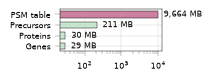

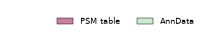

In [15]:
from matplotlib import colors as mcolors
import os

# Get dataset sizes on disk
dataset_paths = {
    "PSM table": report_path,
    "Precursors": "../albrecht.precursors.h5ad",
    "Proteins": "../albrecht.proteins.h5ad",
    "Genes": "../albrecht.genes.h5ad",
}

dataset_sizes = pd.DataFrame({k: os.path.getsize(v) for k, v in dataset_paths.items()}, index=[0]).T

dataset_sizes.columns = ["Size (bytes)"]
dataset_sizes["Size (MB)"] = dataset_sizes["Size (bytes)"] / 1024**2
dataset_sizes["Size (GB)"] = dataset_sizes["Size (bytes)"] / 1024**3
dataset_sizes["modality"] = dataset_sizes.index

color_dict = {
    "PSM table": apt.pl.BaseColors.get("red"),
    "Precursors": apt.pl.BaseColors.get("lightgreen"),
    "Proteins": apt.pl.BaseColors.get("lightgreen"),
    "Genes": apt.pl.BaseColors.get("lightgreen"),
}

fig, axm = apt.pl.create_figure(1, 1, figsize=(2, 0.7))
ax = axm.next()

sizes = dataset_sizes.loc[["Genes", "Proteins", "Precursors", "PSM table"], "Size (MB)"]  # small→large, PSM on 
pos = range(len(sizes))

bars = ax.barh(pos, sizes.values, height=0.6)
for p, (label, val) in zip(pos, sizes.items()):
    bars[p].set_facecolor(mcolors.to_rgba(color_dict[label], alpha=0.5))
    bars[p].set_edgecolor("black")
    bars[p].set_linewidth(apt.pl.figure.config["linewidths"]["medium"])
    ax.text(val, p, f"  {val:,.0f} MB", va="center", ha="left",
            fontsize=apt.pl.figure.config["axes"]["tick_size"])

ax.set_yticks(list(pos))
ax.set_yticklabels(sizes.index)
ax.set_xscale("log")


apt.pl.label_axes(
    ax, 
    # xlabel="Size (MB)", 
    # title="PSM report vs. AnnData"
)
apt.pl.save_figure(
    fig, 
    "supplementary_02_scalability-demo_PCAn_dataset_sizes.png",
    figure_output_dir, 
    dpi=600, 
    transparent=True
)

# two-column legend
fig, axm = apt.pl.create_figure(1, 1, figsize=(2, 0.3))
ax = axm.next()
ax.axis("off")
legend_dict = {
    "PSM table": apt.pl.BaseColors.get("red", alpha=0.5),
    "AnnData": apt.pl.BaseColors.get("lightgreen", alpha=0.5),
}
apt.pl.add_legend_to_axes(
    ax,
    levels = legend_dict,
    frameon = False,
    ncol = 2,
)
apt.pl.save_figure(
    fig=fig,
    filename="supplementary_02_scalability-demo_PCAn_dataset_sizes_legend.png",
    output_dir=figure_output_dir,
    dpi=600,
    transparent=True,
)
